# Step 2. 강원도 산불발생 날씨·지수 대조군 재분석

산불 발생과 비발생 비교를 위한 사건, 격자, 누수 방지 기상, 캐나다 지수를 준비한다.

## 현재 구현 범위

이 노트북은 **원천 데이터 경로 확인, 로딩, 필수 스키마 검증, 시간 파싱,
기본 행 수 감사**까지 구현한다. 통계 분석과 시각화는 이후 셀에서 이어서 작성한다.

공통 데이터 계약은 `README.md`를 따른다. Step 2~6에서 캐나다 지수를 사건 시각에
결합할 때는 12시 이전이면 전일 정오, 12시 이후이면 당일 정오 자료만 사용한다.

결과 해석은 이 노트북에 작성하지 않는다. 결과표와 플롯을 함께 검토한 해석,
한계와 다음 코드 반영사항은 대응 `진행예정로그.md`에만 기록한다.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd().resolve()
candidates = [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
REPO_ROOT = next(
    (path for path in candidates if (path / "jsw/강원_재_EDA/re_eda_common.py").exists()),
    Path(r"D:/farm-system-public-02"),
)
MODULE_DIR = REPO_ROOT / "jsw/강원_재_EDA"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from re_eda_common import (
    DATA_PATHS,
    DERIVED_WEATHER_COLUMNS,
    RAW_WEATHER_COLUMNS,
    add_canadian_asof_keys,
    check_sources,
    configure_notebook,
    frame_inventory,
    load_access_lines,
    load_canadian_indices,
    load_dem_metadata,
    load_fire,
    load_grid_bundle,
    load_hourly_weather,
    load_infrastructure,
    load_landcover,
    load_roads,
    load_terrain,
)

configure_notebook()

REPO_ROOT: D:\farm-system-public-02
matplotlib font.family: ['Malgun Gothic']


## 1. 원천 파일 존재 여부

In [2]:
SOURCE_KEYS = ['fire', 'weather_cells', 'weather_grid', 'weather_hourly_derived', 'climate_type', 'canada_ffmc', 'canada_fwi']
source_audit = check_sources(SOURCE_KEYS)
display(source_audit)

,데이터키,존재,크기_MB,경로
0,fire,True,0.39,D:\farm-system-public-02\data\강원도_데이터\강원도_산불발생...
1,weather_cells,True,0.05,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
2,weather_grid,True,0.09,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
3,weather_hourly_derived,True,438.45,D:\farm-system-public-02\data\학습데이터\기상_시간단위_파생...
4,climate_type,True,0.00,D:\farm-system-public-02\data\강원도_날씨데이터\강원도날씨_...
5,canada_ffmc,True,6.75,D:\farm-system-public-02\data\학습데이터\캐나다_FFMC_선...
6,canada_fwi,True,10.10,D:\farm-system-public-02\data\학습데이터\캐나다_FWI_일단...


## 2. 산불 및 기상격자 로딩

In [3]:
fire, fire_points = load_fire()
grid_bundle = load_grid_bundle()
weather_cells = grid_bundle["cells"]
climate_type = grid_bundle["climate"]
weather_grid = grid_bundle["grid"]

print("산불:", len(fire), "건")
print("좌표 유효 산불:", len(fire_points), "건")
print("발생시각 결측:", int(fire["기준시각"].isna().sum()), "건")
display(fire.head())

산불: 3405 건
좌표 유효 산불: 3405 건
발생시각 결측: 0 건


,fire_id,연도,월,일,시간,진화소요시간(HH),위도,경도,발생지역시도명,발생지역시군구명,발생지역읍면동명,발생지역리명,발생지역번지,발생원인명,피해면적(ha),피해금액,발생일시,기준시각,발생날짜,번지유형
0,F_003556,2020,4,30,18,NaN,37.432421,127.803653,강원특별자치도,원주시,지정면,월송리,산172,NaN,NaN,NaN,2020-04-30 18:00:00,2020-04-30 18:00:00,2020-04-30,임야번지(산)
1,F_006688,2020,4,30,18,NaN,37.432421,127.803653,강원특별자치도,원주시,지정면,월송리,산172,NaN,NaN,NaN,2020-04-30 18:00:00,2020-04-30 18:00:00,2020-04-30,임야번지(산)
2,F_006690,2020,5,1,22,NaN,37.773694,127.446131,강원특별자치도,고성군,토성면,도원리,NaN,NaN,NaN,NaN,2020-05-01 22:00:00,2020-05-01 22:00:00,2020-05-01,일반번지
3,F_007615,2020,1,1,12,NaN,37.761451,128.841125,강원특별자치도,강릉시,성산면,위촌리,877,NaN,NaN,NaN,2020-01-01 12:00:00,2020-01-01 12:00:00,2020-01-01,일반번지
4,F_007616,2020,1,3,12,NaN,37.329735,129.043221,강원특별자치도,삼척시,신기면,대이리,30,NaN,NaN,NaN,2020-01-03 12:00:00,2020-01-03 12:00:00,2020-01-03,일반번지


## 3. 누수 방지 시간기상 파생자료 로딩

In [4]:
hourly_weather = load_hourly_weather(
    derived=True,
    columns=DERIVED_WEATHER_COLUMNS,
)
print("기간:", hourly_weather["일시"].min(), "~", hourly_weather["일시"].max())
print("기상셀 수:", hourly_weather["기상셀ID"].nunique())
display(hourly_weather.head())

기간: 2020-01-01 00:00:00 ~ 2021-12-31 23:00:00
기상셀 수: 92


,기상셀ID,일시,시점_기온_C,시점_풍속_m_s,시점_습도_pct,직전24h_평균풍속,직전24h_최대풍속,직전48h_평균풍속,직전48h_최대풍속,직전24h_평균기온_C,직전24h_평균습도,직전24h_최소습도,직전48h_평균습도,직전48h_최소습도,직전24h_강수량합,직전48h_강수량합,시점_풍향_deg,풍향_sin,풍향_cos,서풍계열_여부,시점_현지기압_hPa,시점_해면기압_hPa,기압변동_3h,D-1_최소습도_pct,D-1_평균습도_pct,D-1_강수량합_mm,D-2_최소습도_pct,D-3_최소습도_pct
0,YD_0001,2020-01-01 00:00:00,-4.18,4.52,29.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,226.26,-0.722485,-0.691387,1,999.82,1021.12,NaN,NaN,NaN,NaN,NaN,NaN
1,YD_0001,2020-01-01 01:00:00,-3.59,4.28,40.85,4.520,4.52,4.520,4.52,-4.1800,29.0000,29.0,29.0000,29.0,0.0,0.0,235.90,-0.828060,-0.560639,1,999.68,1020.90,NaN,NaN,NaN,NaN,NaN,NaN
2,YD_0001,2020-01-01 02:00:00,-2.97,4.01,44.09,4.400,4.52,4.400,4.52,-3.8850,34.9250,29.0,34.9250,29.0,0.0,0.0,243.05,-0.891402,-0.453213,1,999.70,1020.91,NaN,NaN,NaN,NaN,NaN,NaN
3,YD_0001,2020-01-01 03:00:00,-2.79,4.89,50.15,4.270,4.52,4.270,4.52,-3.5800,37.9800,29.0,37.9800,29.0,0.0,0.0,233.54,-0.804272,-0.594261,1,999.58,1020.75,-0.24,NaN,NaN,NaN,NaN,NaN
4,YD_0001,2020-01-01 04:00:00,-2.54,4.32,52.23,4.425,4.89,4.425,4.89,-3.3825,41.0225,29.0,41.0225,29.0,0.0,0.0,245.21,-0.907851,-0.419294,1,999.42,1020.55,-0.26,NaN,NaN,NaN,NaN,NaN


## 4. 캐나다 지수 및 사건별 as-of 키 준비

In [5]:
canadian_indices = load_canadian_indices()
fire = add_canadian_asof_keys(fire, time_column="기준시각")

asof_violations = (
    fire["캐나다지수_기준시각"] > fire["기준시각"]
).sum()
assert asof_violations == 0
display(
    fire[
        [
            "fire_id",
            "기준시각",
            "캐나다지수_기준날짜",
            "캐나다지수_기준시각",
            "캐나다지수_시차시간",
            "캐나다지수_당일사용여부",
        ]
    ].head()
)

,fire_id,기준시각,캐나다지수_기준날짜,캐나다지수_기준시각,캐나다지수_시차시간,캐나다지수_당일사용여부
0,F_003556,2020-04-30 18:00:00,2020-04-30,2020-04-30 12:00:00,6.0,True
1,F_006688,2020-04-30 18:00:00,2020-04-30,2020-04-30 12:00:00,6.0,True
2,F_006690,2020-05-01 22:00:00,2020-05-01,2020-05-01 12:00:00,10.0,True
3,F_007615,2020-01-01 12:00:00,2020-01-01,2020-01-01 12:00:00,0.0,True
4,F_007616,2020-01-03 12:00:00,2020-01-03,2020-01-03 12:00:00,0.0,True


## 로딩 결과 요약

In [6]:
loaded_frames = {
    "fire": fire,
    "fire_points": fire_points,
    "weather_cells": weather_cells,
    "climate_type": climate_type,
    "weather_grid": weather_grid,
    "hourly_weather": hourly_weather,
    "canadian_indices": canadian_indices,
}
display(frame_inventory(loaded_frames))

,이름,행,열,메모리_MB,CRS
0,fire,3405,25,0.86,NaN
1,fire_points,3405,21,0.78,EPSG:4326
2,weather_cells,92,12,0.05,NaN
3,climate_type,92,3,0.00,NaN
4,weather_grid,92,12,0.01,EPSG:4326
5,hourly_weather,1614048,28,355.57,NaN
6,canadian_indices,67252,16,8.66,NaN


## 5. S2-01 산불-기상셀 공간조인과 미매칭 감사

,총_건수,매칭_건수,미매칭_건수,매칭률_pct
0,3405,3401,4,99.882526


,fire_id,발생일시
2,F_006690,2020-05-01 22:00:00
2064,F_009678,2021-02-03 16:00:00
3051,F_010665,2021-05-11 13:00:00
3190,F_010893,2020-04-16 13:00:00


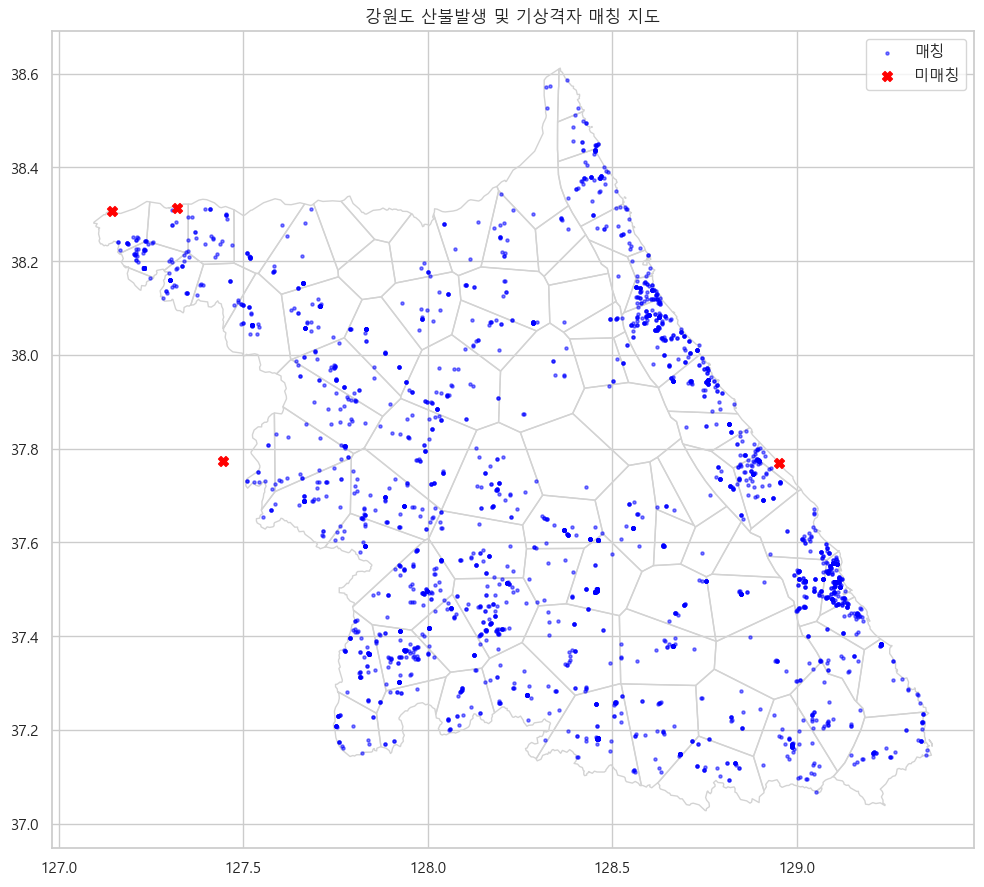

In [7]:

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 좌표계 일치 확인 및 공간조인
if fire_points.crs != weather_grid.crs:
    fire_points = fire_points.to_crs(weather_grid.crs)

fire_joined = gpd.sjoin(fire_points, weather_grid[['기상셀ID', 'geometry']], how="left", predicate="within")

Path("outputs/Step2/tables").mkdir(parents=True, exist_ok=True)
Path("outputs/Step2/plots").mkdir(parents=True, exist_ok=True)

# 1. 매칭률 계산
match_rate = pd.DataFrame({
    '총_건수': [len(fire_joined)],
    '매칭_건수': [fire_joined['기상셀ID'].notna().sum()],
    '미매칭_건수': [fire_joined['기상셀ID'].isna().sum()],
    '매칭률_pct': [fire_joined['기상셀ID'].notna().mean() * 100]
})
display(match_rate)
match_rate.to_csv("outputs/Step2/tables/S2-01_matching_rate.csv", index=False, encoding='utf-8-sig')

# 2. 미매칭 목록
unmatched = fire_joined[fire_joined['기상셀ID'].isna()]
if len(unmatched) > 0:
    display(unmatched[['fire_id', '발생일시']]) # available columns
    unmatched.to_csv("outputs/Step2/tables/S2-01_unmatched_list.csv", index=False, encoding='utf-8-sig')
else:
    pd.DataFrame(columns=['fire_id']).to_csv("outputs/Step2/tables/S2-01_unmatched_list.csv", index=False, encoding='utf-8-sig')

# 3. 매칭 지도 시각화
fig, ax = plt.subplots(figsize=(10, 10))
weather_grid.plot(ax=ax, facecolor="none", edgecolor="lightgray")
fire_joined[fire_joined['기상셀ID'].notna()].plot(ax=ax, color="blue", markersize=5, alpha=0.5, label="매칭")
if len(unmatched) > 0:
    unmatched.plot(ax=ax, color="red", markersize=50, marker='X', label="미매칭")
ax.legend()
ax.set_title("강원도 산불발생 및 기상격자 매칭 지도")
plt.tight_layout()
plt.savefig("outputs/Step2/plots/S2-01_matching_map.png", dpi=300)
plt.show()


## 6. S2-02 발생 지도와 월별·시간대별 분포

,월,시간,기후지형유형,번지유형,건수,비율_pct
153,2,10,영서 내륙형,일반번지,311,9.144369
169,2,13,영동 해안형,일반번지,171,5.027933
151,2,10,영동 해안형,일반번지,158,4.645692
753,10,15,영서 내륙형,일반번지,100,2.940312
150,2,10,영동 해안형,임야번지(산),68,1.999412


기후지형유형,영동 해안형,영서 내륙형,고지·산간형
월,,,
1,104,66,36
2,682,604,203
3,60,148,30
4,60,218,50
5,27,98,22
6,12,13,3
7,0,3,1
8,0,1,0
9,2,4,1


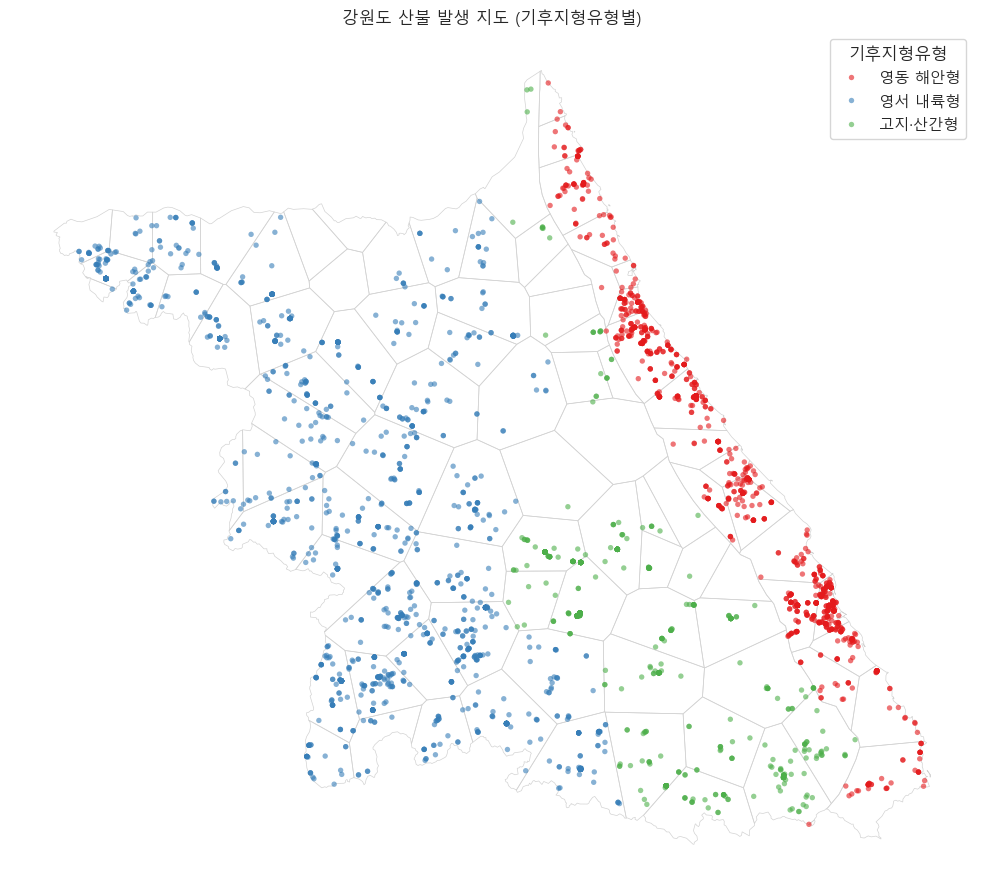

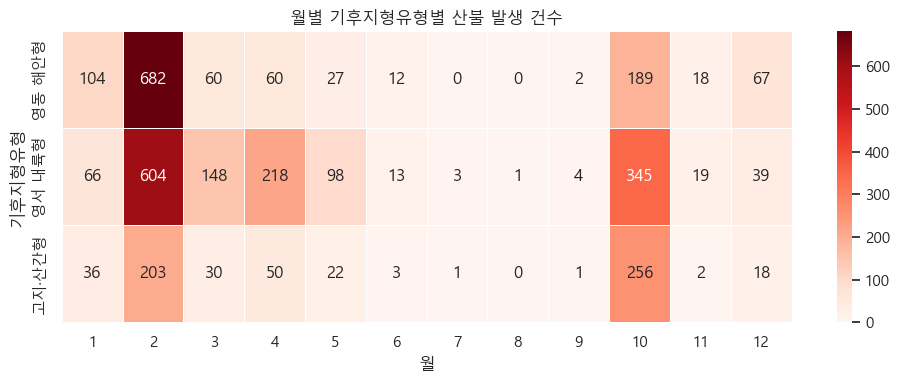

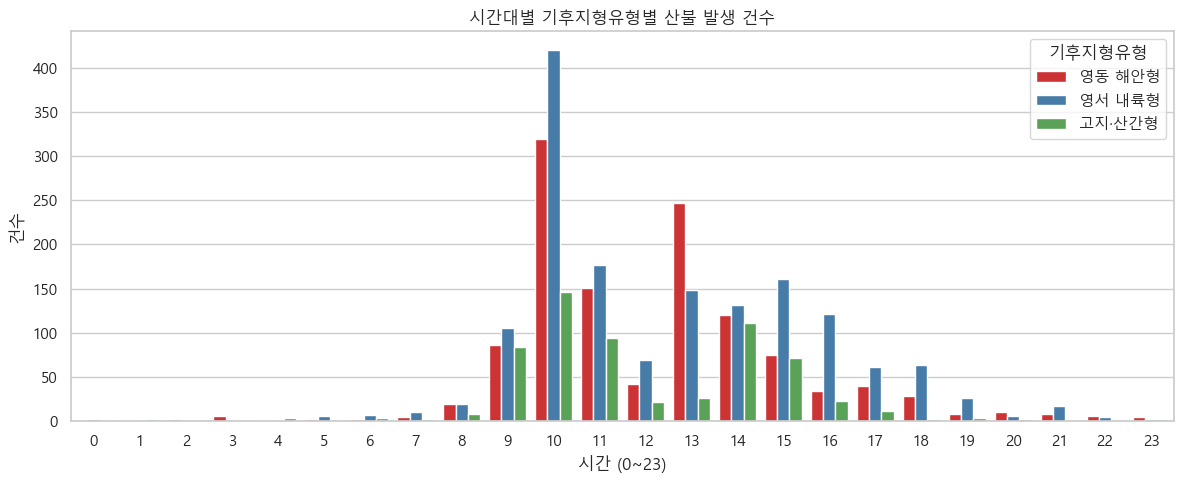

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np

# 1. 매칭된 산불 데이터 필터링 및 기후지형유형 결합
fire_matched = fire_joined.dropna(subset=['기상셀ID']).copy()
fire_matched = fire_matched.merge(climate_type[['기상셀ID', '기후지형유형']], on='기상셀ID', how='left')

# 범주형 순서 고정
climate_order = ['영동 해안형', '영서 내륙형', '고지·산간형']
fire_matched['기후지형유형'] = pd.Categorical(fire_matched['기후지형유형'], categories=climate_order, ordered=True)

bungi_order = ['임야번지(산)', '일반번지']
fire_matched['번지유형'] = pd.Categorical(fire_matched['번지유형'], categories=bungi_order, ordered=True)

# 2. 결과표 생성 (월, 시간, 유형별 건수)
agg_counts = fire_matched.groupby(['월', '시간', '기후지형유형', '번지유형'], observed=False).size().reset_index(name='건수')
agg_counts = agg_counts[agg_counts['건수'] > 0]
agg_counts['비율_pct'] = (agg_counts['건수'] / len(fire_matched)) * 100

display(agg_counts.sort_values(by='건수', ascending=False).head())
agg_counts.to_csv("outputs/Step2/tables/S2-02_monthly_hourly_type_counts.csv", index=False, encoding='utf-8-sig')

monthly_region = fire_matched.groupby(['월', '기후지형유형'], observed=False).size().unstack(fill_value=0)
display(monthly_region)

# 3. 산불 발생 지도 (권역별 색상)
fig, ax = plt.subplots(figsize=(10, 10))
weather_grid.plot(ax=ax, facecolor="none", edgecolor="lightgray", linewidth=0.5)
sns.scatterplot(
    data=fire_matched, 
    x=fire_matched.geometry.x, 
    y=fire_matched.geometry.y, 
    hue='기후지형유형', 
    palette='Set1', 
    s=15, 
    alpha=0.6, 
    edgecolor='none',
    ax=ax
)
ax.set_title("강원도 산불 발생 지도 (기후지형유형별)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("outputs/Step2/plots/S2-02_fire_map.png", dpi=300)
plt.show()

# 4. 월 × 기후지형유형 Heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(monthly_region.T, annot=True, fmt='d', cmap='Reds', linewidths=.5)
plt.title("월별 기후지형유형별 산불 발생 건수")
plt.ylabel("기후지형유형")
plt.xlabel("월")
plt.tight_layout()
plt.savefig("outputs/Step2/plots/S2-02_month_type_heatmap.png", dpi=300)
plt.show()

# 5. 시간대별 분포 Plot
plt.figure(figsize=(12, 5))
sns.countplot(data=fire_matched, x='시간', hue='기후지형유형', palette='Set1')
plt.title("시간대별 기후지형유형별 산불 발생 건수")
plt.xlabel("시간 (0~23)")
plt.ylabel("건수")
plt.legend(title='기후지형유형')
plt.tight_layout()
plt.savefig("outputs/Step2/plots/S2-02_hourly_plot.png", dpi=300)
plt.show()


### S2-03. 전체 비발생 후보 생성 및 누수·중복 감사

전체 시간기상 레코드: 1,614,048 건
산불 발생으로 제외된 레코드: 1,150 건
전체 비발생 후보 수: 1,612,898 건


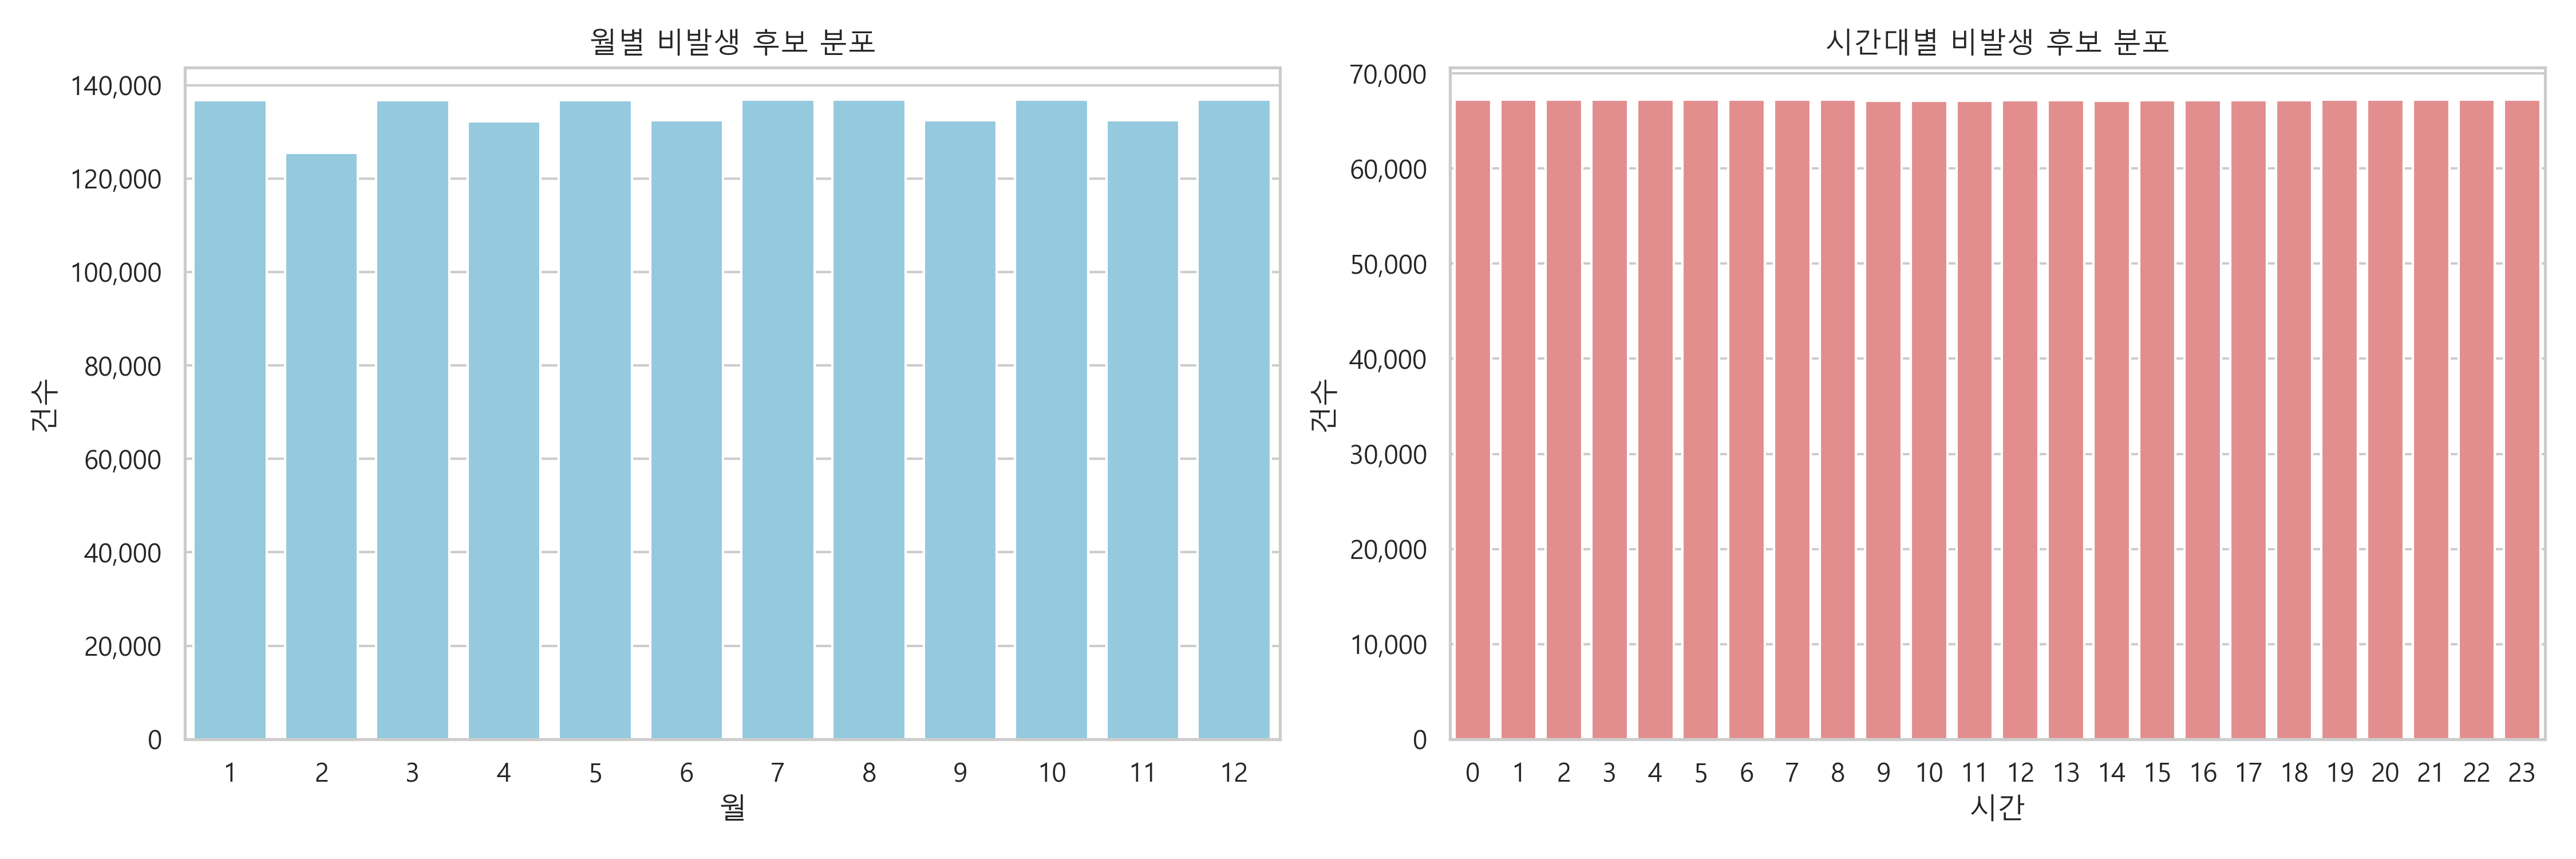

In [ ]:
# S2-03 로직
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 산불-기상셀 매칭 기준시각 준비
fire_joined = gpd.sjoin(fire_points, weather_grid, how='left', predicate='within')
fire_matched = fire_joined.dropna(subset=['기상셀ID']).copy()
fire_matched['기준시각'] = pd.to_datetime(fire_matched['기준시각'])

fire_events = set(zip(fire_matched['기상셀ID'], fire_matched['기준시각']))

# 2. 전체 비발생 후보 식별
fire_keys = pd.DataFrame(list(fire_events), columns=['기상셀ID', '일시'])
fire_keys['is_fire'] = True

hourly_keys = hourly_weather[['기상셀ID', '일시']]
merged = hourly_keys.merge(fire_keys, on=['기상셀ID', '일시'], how='left')
non_fire_mask = merged['is_fire'].isna()

candidate_count = non_fire_mask.sum()
excluded_count = (~non_fire_mask).sum()

print(f"전체 시간기상 레코드: {len(hourly_weather):,} 건")
print(f"산불 발생으로 제외된 레코드: {excluded_count:,} 건")
print(f"전체 비발생 후보 수: {candidate_count:,} 건")

# 3. 셀, 월, 시간 구성 분포
candidate_months = hourly_weather.loc[non_fire_mask, '일시'].dt.month
candidate_hours = hourly_weather.loc[non_fire_mask, '일시'].dt.hour

monthly_counts = candidate_months.value_counts().sort_index()
hourly_counts = candidate_hours.value_counts().sort_index()

# 4. 결과표 저장
outputs_dir = REPO_ROOT / "jsw/강원_재_EDA/outputs/Step2"
outputs_dir.joinpath("tables").mkdir(parents=True, exist_ok=True)
outputs_dir.joinpath("plots").mkdir(parents=True, exist_ok=True)

composition_df = pd.DataFrame({
    '항목': ['전체_레코드', '제외_레코드', '후보_레코드'],
    '건수': [len(hourly_weather), excluded_count, candidate_count]
})
composition_df.to_csv(outputs_dir / "tables/S2-03_candidate_counts.csv", index=False, encoding='utf-8-sig')

month_hour_dist = pd.DataFrame({
    '월': monthly_counts.index.tolist() + [None]*(24-12),
    '월_건수': monthly_counts.values.tolist() + [None]*(24-12),
    '시간': hourly_counts.index,
    '시간_건수': hourly_counts.values
})
month_hour_dist.to_csv(outputs_dir / "tables/S2-03_month_hour_distribution.csv", index=False, encoding='utf-8-sig')

# 5. 표본 구성 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, ax=axes[0], color='skyblue')
axes[0].set_title("월별 비발생 후보 분포")
axes[0].set_xlabel("월")
axes[0].set_ylabel("건수")
axes[0].set_yticklabels([f'{int(y):,}' for y in axes[0].get_yticks()])

sns.barplot(x=hourly_counts.index, y=hourly_counts.values, ax=axes[1], color='lightcoral')
axes[1].set_title("시간대별 비발생 후보 분포")
axes[1].set_xlabel("시간")
axes[1].set_ylabel("건수")
axes[1].set_yticklabels([f'{int(y):,}' for y in axes[1].get_yticks()])

plt.tight_layout()
plt.savefig(outputs_dir / "plots/S2-03_candidate_distribution.png", dpi=300)
plt.show()

del fire_joined, fire_keys, hourly_keys, merged, candidate_months, candidate_hours